# 🛍️ Product Review Analyzer
## End-to-End NLP Pipeline for Amazon Reviews
**Models Used:**
- DistilBERT → Sentiment Analysis
- BERT → Category Classification  
- RoBERTa → Aspect Analysis
- BART → Review Summarization

**Dataset:** Amazon Reviews (HuggingFace)
**Goal:** Complete analysis of any product review

In [1]:
!pip install transformers datasets evaluate \
             accelerate sentencepiece -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.8 MB/s eta 0:00:00


In [2]:
import accelerate, transformers
print(accelerate.__version__)
print(transformers.__version__)

1.13.0
5.0.0


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import gradio
import sklearn
import evaluate
import sentencepiece
import warnings
import datasets
warnings.filterwarnings('ignore')

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForSeq2SeqLM,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    pipeline
)

# Verify versions
import transformers
print(f"Transformers : {transformers.__version__}")
print(f"Torch        : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Transformers : 5.0.0
Torch        : 2.10.0+cu128
CUDA available: True


In [4]:
print("accelerate:", accelerate.__version__)
print("transformers:", transformers.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("datasets:", datasets.__version__)
print("torch:", torch.__version__)
print("gradio:", gradio.__version__)
print("scikit-learn:", sklearn.__version__)
print("evaluate:", evaluate.__version__)
print("sentencepiece:", sentencepiece.__version__)

accelerate: 1.13.0
transformers: 5.0.0
numpy: 2.0.2
pandas: 2.2.2
datasets: 4.0.0
torch: 2.10.0+cu128
gradio: 5.50.0
scikit-learn: 1.6.1
evaluate: 0.4.6
sentencepiece: 0.2.1


In [5]:
# Amazon reviews polarity dataset
# 2 classes: 1=Negative, 2=Positive
# 3.6M training reviews!
dataset = load_dataset(
    "amazon_polarity",
    trust_remote_code=True
)

print(f"\nDataset structure:")
print(dataset)
print(f"\nFirst example:")
print(f"Title  : {dataset['train'][0]['title']}")
print(f"Content: {dataset['train'][0]['content'][:200]}...")
print(f"Label  : {dataset['train'][0]['label']}")
print(f"(1=Negative, 2=Positive)")


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'amazon_polarity' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'amazon_polarity' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

amazon_polarity/train-00000-of-00004.par(…):   0%|          | 0.00/260M [00:00<?, ?B/s]

amazon_polarity/train-00001-of-00004.par(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

amazon_polarity/train-00002-of-00004.par(…):   0%|          | 0.00/255M [00:00<?, ?B/s]

amazon_polarity/train-00003-of-00004.par(…):   0%|          | 0.00/254M [00:00<?, ?B/s]

amazon_polarity/test-00000-of-00001.parq(…):   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]


Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 3600000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 400000
    })
})

First example:
Title  : Stuning even for the non-gamer
Content: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I...
Label  : 1
(1=Negative, 2=Positive)


EXPLORATORY DATA ANALYSIS

Dataset shape: (5000, 3)

Columns: ['label', 'title', 'content']

Label distribution:
label
0    2692
1    2308
Name: count, dtype: int64

Text length stats:
count    5000.000000
mean      433.491200
std       236.217292
min       100.000000
25%       236.000000
50%       387.000000
75%       596.000000
max      1013.000000
Name: text_length, dtype: float64

Word count stats:
count    5000.000000
mean       78.931600
std        42.627009
min        15.000000
25%        43.000000
50%        70.000000
75%       108.000000
max       200.000000
Name: word_count, dtype: float64


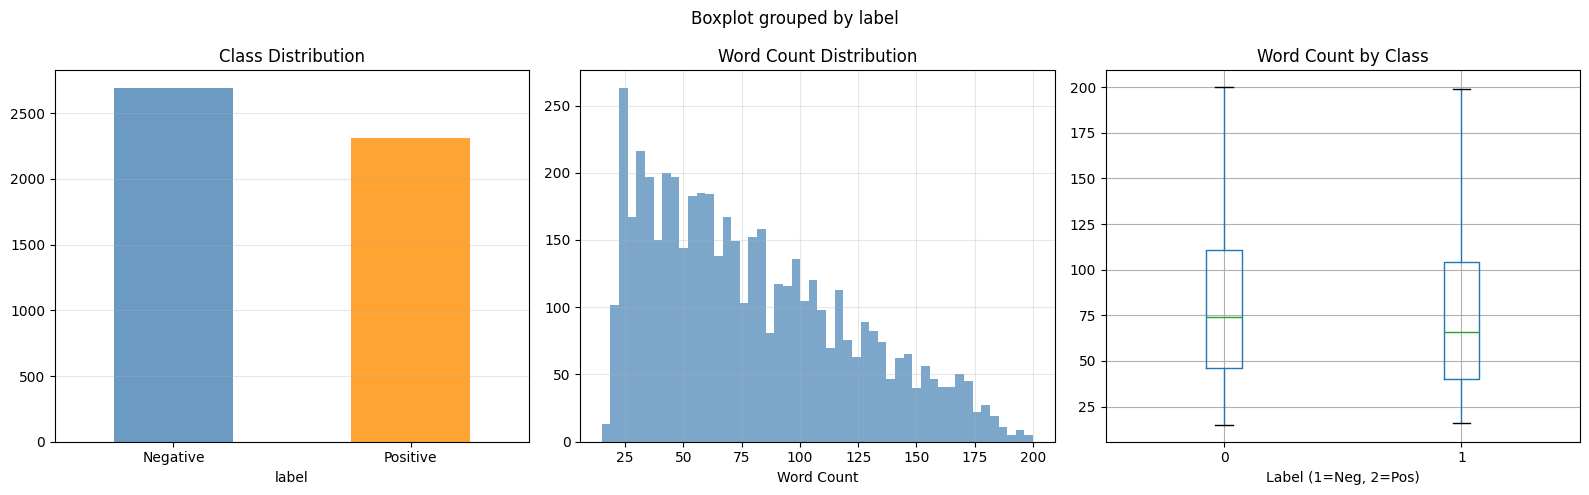


EDA plots saved!


In [6]:
# Exploratory Data Analysis
print("="*55)
print("EXPLORATORY DATA ANALYSIS")
print("="*55)

# Use small sample for EDA
sample = dataset['train'].select(range(5000))
df     = pd.DataFrame(sample)

print(f"\nDataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())

# Combine title and content
df['text'] = df['title'] + " " + df['content']

# Text length analysis
df['text_length'] = df['text'].apply(len)
df['word_count']  = df['text'].apply(
    lambda x: len(x.split()))

print(f"\nText length stats:")
print(df['text_length'].describe())

print(f"\nWord count stats:")
print(df['word_count'].describe())

# ── Visualizations ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Class distribution
df['label'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'darkorange'],
    alpha=0.8
)
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(
    ['Negative', 'Positive'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Text length distribution
df['word_count'].hist(
    bins=50, ax=axes[1],
    color='steelblue', alpha=0.7
)
axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('Word Count')
axes[1].grid(True, alpha=0.3)

# Word count by class
df.boxplot(
    column='word_count',
    by='label',
    ax=axes[2]
)
axes[2].set_title('Word Count by Class')
axes[2].set_xlabel('Label (1=Neg, 2=Pos)')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()
print("\nEDA plots saved!")

In [7]:
# Prepare Training Data
print("Preparing data for training...")

# Use subset for faster training
TRAIN_SIZE = 5000
TEST_SIZE  = 1000

# Create subsets
train_data = dataset['train'].shuffle(seed=42)\
                              .select(range(TRAIN_SIZE))
test_data  = dataset['test'].shuffle(seed=42)\
                             .select(range(TEST_SIZE))

def prepare_example(example):
    return {
        'text' : example['title'] + " " + example['content'],
        'label': example['label']  # Already 0,1 ✅ no change needed
    }

train_data = train_data.map(prepare_example)
test_data  = test_data.map(prepare_example)

# Remove original columns
train_data = train_data.remove_columns(
    ['title', 'content'])
test_data  = test_data.remove_columns(
    ['title', 'content'])

print(f"Train size : {len(train_data):,}")
print(f"Test size  : {len(test_data):,}")
print(f"\nSample after preparation:")
print(f"Text  : {train_data[0]['text'][:150]}...")
print(f"Label : {train_data[0]['label']} "
      f"({'Positive' if train_data[0]['label']==1 else 'Negative'})")

# Check class balance
labels     = train_data['label']
n_pos      = sum(labels)
n_neg      = len(labels) - n_pos
print(f"\nClass balance:")
print(f"Positive: {n_pos} ({n_pos/len(labels)*100:.1f}%)")
print(f"Negative: {n_neg} ({n_neg/len(labels)*100:.1f}%)")

Preparing data for training...


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Train size : 5,000
Test size  : 1,000

Sample after preparation:
Text  : Anyone who likes this better than the Pekinpah is a moron. All the pretty people in this film. Even the Rudy character played by Michael Madsen. This ...
Label : 0 (Negative)

Class balance:
Positive: 2452 (49.0%)
Negative: 2548 (51.0%)


In [8]:
# Tokenization
MODEL_NAME = "distilbert-base-uncased"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(
        examples['text'],
        truncation = True,
        max_length = 256
    )

print("Tokenizing...")
tokenized_train = train_data.map(tokenize, batched=True)
tokenized_test  = test_data.map(tokenize, batched=True)

print(f"Done!")
print(f"Features: {tokenized_train.features}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing...


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Done!
Features: {'label': ClassLabel(names=['negative', 'positive']), 'text': Value('string'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}


In [9]:
print(set(tokenized_train['label']))
print(set(tokenized_test['label']))

{0, 1}
{0, 1}


In [10]:
#Fine-tune DistilBERT for Sentiment
print("Loading DistilBERT...")
sentiment_model = AutoModelForSequenceClassification\
    .from_pretrained(MODEL_NAME, num_labels=2)

sentiment_model.config.id2label = {
    0: "NEGATIVE", 1: "POSITIVE"}
sentiment_model.config.label2id = {
    "NEGATIVE": 0, "POSITIVE": 1}

# Metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_metric.compute(
            predictions=predictions,
            references=labels)['accuracy'],
        'f1': f1_metric.compute(
            predictions=predictions,
            references=labels,
            average='weighted')['f1']
    }

# Training args
sentiment_args = TrainingArguments(
    output_dir     = "./sentiment-model",
    num_train_epochs = 3,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 32,
    learning_rate  = 2e-5,
    warmup_steps   = 100,
    weight_decay   = 0.01,
    eval_strategy  = "epoch",
    save_strategy  = "epoch",
    load_best_model_at_end = True,
    logging_steps  = 50,
    seed           = 42,
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer)

# Trainer
sentiment_trainer = Trainer(
    model            = sentiment_model,
    args             = sentiment_args,
    train_dataset    = tokenized_train,
    eval_dataset     = tokenized_test,
    processing_class = tokenizer,
    data_collator    = data_collator,
    compute_metrics  = compute_metrics,
)

print("Training Sentiment Model...")
print("Expected: ~5-8 minutes on T4 GPU")
sentiment_trainer.train()

Loading DistilBERT...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training Sentiment Model...
Expected: ~5-8 minutes on T4 GPU


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=471, training_loss=0.2286710399984048, metrics={'train_runtime': 347.8523, 'train_samples_per_second': 43.122, 'train_steps_per_second': 1.354, 'total_flos': 861358910745120.0, 'train_loss': 0.2286710399984048, 'epoch': 3.0})

In [11]:
#Evaluate Sentiment Model
print("="*55)
print("SENTIMENT MODEL RESULTS")
print("="*55)

results = sentiment_trainer.evaluate()
print(f"Accuracy : {results['eval_accuracy']:.4f} "
      f"({results['eval_accuracy']*100:.2f}%)")
print(f"F1 Score : {results['eval_f1']:.4f}")
print(f"Loss     : {results['eval_loss']:.4f}")

SENTIMENT MODEL RESULTS


Accuracy : 0.9290 (92.90%)
F1 Score : 0.9289
Loss     : 0.2045


In [12]:
# Category Classification

print("Loading zero-shot classifier...")
category_classifier = pipeline(
    "zero-shot-classification",
    model  = "facebook/bart-large-mnli",
    device = 0 if torch.cuda.is_available() else -1
)

# Product categories
CATEGORIES = [
    "Electronics",
    "Clothing and Fashion",
    "Books and Literature",
    "Food and Grocery",
    "Sports and Outdoors",
    "Home and Kitchen",
    "Beauty and Personal Care",
    "Toys and Games"
]

def classify_category(text):
    """Classify review into product category"""
    result = category_classifier(
        text[:512],  # limit length
        candidate_labels = CATEGORIES,
        multi_label      = False
    )
    return {
        'category': result['labels'][0],
        'score'   : result['scores'][0]
    }

# Test it
test_reviews = [
    "The battery life on this laptop is amazing!",
    "This shirt fits perfectly and looks great",
    "Fantastic novel, couldn't put it down!",
    "These running shoes are very comfortable",
]

print("\nCategory Classification Test:")
print("-"*55)
for review in test_reviews:
    result = classify_category(review)
    print(f"Review  : '{review[:50]}'")
    print(f"Category: {result['category']} "
          f"({result['score']:.3f})")
    print()

Loading zero-shot classifier...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Category Classification Test:
-------------------------------------------------------
Review  : 'The battery life on this laptop is amazing!'
Category: Electronics (0.454)

Review  : 'This shirt fits perfectly and looks great'
Category: Clothing and Fashion (0.825)

Review  : 'Fantastic novel, couldn't put it down!'
Category: Books and Literature (0.893)

Review  : 'These running shoes are very comfortable'
Category: Sports and Outdoors (0.867)



In [13]:
# Aspect Analysis with RoBERTa
print("Loading aspect analyzer...")

# Use zero-shot for aspect analysis too
aspect_classifier = pipeline(
    "zero-shot-classification",
    model  = "cross-encoder/nli-roberta-base",
    device = 0 if torch.cuda.is_available() else -1
)

# Common product aspects
ASPECTS = [
    "price and value",
    "quality and durability",
    "delivery and shipping",
    "customer service",
    "ease of use",
    "design and appearance",
    "performance and speed",
    "battery life"
]

def analyze_aspects(text):
    """Find main aspects mentioned in review"""
    result = aspect_classifier(
        text[:512],
        candidate_labels = ASPECTS,
        multi_label      = True  # multiple aspects!
    )
    # Return top 3 aspects with score > 0.3
    aspects = [
        (label, score)
        for label, score in zip(
            result['labels'],
            result['scores']
        )
        if score > 0.3
    ][:3]
    return aspects

# Test aspect analysis
test_reviews = [
    "The phone battery dies quickly but camera is excellent",
    "Very expensive but the quality is outstanding",
    "Fast delivery! Product looks great but a bit fragile",
    "Easy to use but customer service was unhelpful",
]

print("\nAspect Analysis Test:")
print("-"*55)
for review in test_reviews:
    aspects = analyze_aspects(review)
    print(f"Review  : '{review[:60]}'")
    print(f"Aspects :")
    for aspect, score in aspects:
        bar = "█" * int(score * 10)
        print(f"  {aspect:<25} {score:.3f} {bar}")
    print()

Loading aspect analyzer...


config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

merges.txt: 0.00B [00:00, ?B/s]

'The read operation timed out' thrown while requesting HEAD https://huggingface.co/cross-encoder/nli-roberta-base/resolve/main/tokenizer.json
Retrying in 1s [Retry 1/5].


tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]


Aspect Analysis Test:
-------------------------------------------------------
Review  : 'The phone battery dies quickly but camera is excellent'
Aspects :
  performance and speed     0.949 █████████
  quality and durability    0.945 █████████
  battery life              0.772 ███████

Review  : 'Very expensive but the quality is outstanding'
Aspects :
  price and value           0.961 █████████
  quality and durability    0.959 █████████
  design and appearance     0.629 ██████

Review  : 'Fast delivery! Product looks great but a bit fragile'
Aspects :
  design and appearance     0.980 █████████
  performance and speed     0.979 █████████
  delivery and shipping     0.955 █████████

Review  : 'Easy to use but customer service was unhelpful'
Aspects :
  ease of use               0.996 █████████
  customer service          0.356 ███



In [41]:
import transformers
print(transformers.__version__)

5.0.0


In [40]:
from transformers import pipeline
from transformers.pipelines import SUPPORTED_TASKS
print(list(SUPPORTED_TASKS.keys()))

['audio-classification', 'automatic-speech-recognition', 'text-to-audio', 'feature-extraction', 'text-classification', 'token-classification', 'question-answering', 'table-question-answering', 'visual-question-answering', 'document-question-answering', 'fill-mask', 'text-generation', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-audio-classification', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'object-detection', 'zero-shot-object-detection', 'depth-estimation', 'video-classification', 'mask-generation', 'image-to-image', 'keypoint-matching', 'any-to-any']


In [47]:
from transformers import BartForConditionalGeneration, BartTokenizer
import torch

print("Loading summarization model...")

bart_tokenizer = BartTokenizer.from_pretrained("facebook/bart-large-xsum")
bart_model     = BartForConditionalGeneration.from_pretrained(
    "facebook/bart-large-xsum"
).to("cuda" if torch.cuda.is_available() else "cpu")

def summarize_review(text, max_length=80):
    if len(text.split()) < 30:
        return text

    inputs = bart_tokenizer(
        text[:512],
        return_tensors = "pt",
        truncation     = True,
        max_length     = 512
    ).to("cuda" if torch.cuda.is_available() else "cpu")

    summary_ids = bart_model.generate(
        inputs["input_ids"],
        max_new_tokens = max_length,
        min_length     = 15,
        length_penalty = 2.0,
        num_beams      = 4,
        early_stopping = True
    )

    return bart_tokenizer.decode(
        summary_ids[0],
        skip_special_tokens=True
    )

# Test
reviews = [
    """This laptop is absolutely incredible. Battery lasts all day,
    easily 10-12 hours of real work. The display is crisp and bright.
    Performance is blazing fast with the new processor. Highly recommend.""",

    """Complete waste of money. Stopped working after a week.
    Customer service was useless and refused a refund.
    Packaging was damaged too. Avoid at all costs."""
]

print("\nSummarization Test:")
print("-"*50)
for review in reviews:
    summary = summarize_review(review)
    print(f"Original : {review[:80].strip()}...")
    print(f"Summary  : {summary}")
    print()

Loading summarization model...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/513 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/309 [00:00<?, ?B/s]


Summarization Test:
--------------------------------------------------
Original : This laptop is absolutely incredible. Battery lasts all day, 
    easily 10-12 h...
Summary  : The Dell XPS 13 is one of the best laptops you can buy at the moment, and it has just been upgraded to the latest generation of processors.

Original : Complete waste of money. Stopped working after a week. 
    Customer service was...
Summary  : Complete waste of money. Stopped working after a week. 
    Customer service was useless and refused a refund. 
    Packaging was damaged too. Avoid at all costs.



In [48]:
# ── Create Sentiment Pipeline ─────────────────
sentiment_pipeline = pipeline(
    "text-classification",
    model     = sentiment_model,
    tokenizer = tokenizer,
    device    = 0 if torch.cuda.is_available() else -1
)

def analyze_sentiment(text):
    """Get sentiment of review"""
    result = sentiment_pipeline(
        text[:512])[0]
    return {
        'label': result['label'],
        'score': result['score']
    }

In [49]:
# ── Complete Product Review Analyzer ──────────
def analyze_review(review_text):
    """
    Complete analysis of a product review.

    Returns:
        sentiment : POSITIVE/NEGATIVE + score
        category  : product category + score
        aspects   : top aspects mentioned
        summary   : concise summary
    """
    print("="*55)
    print("PRODUCT REVIEW ANALYSIS")
    print("="*55)
    print(f"\nReview:\n{review_text[:300]}")
    print("\n" + "-"*55)

    # 1. Sentiment
    sentiment = analyze_sentiment(review_text)
    emoji     = "😊" if sentiment['label'] == \
                "POSITIVE" else "😞"
    print(f"\n{emoji} SENTIMENT: {sentiment['label']} "
          f"(confidence: {sentiment['score']:.3f})")

    # 2. Category
    category = classify_category(review_text)
    print(f"📦 CATEGORY: {category['category']} "
          f"(confidence: {category['score']:.3f})")

    # 3. Aspects
    aspects = analyze_aspects(review_text)
    print(f"🔍 ASPECTS MENTIONED:")
    for aspect, score in aspects:
        print(f"   → {aspect} ({score:.3f})")

    # 4. Summary
    summary = summarize_review(review_text)
    print(f"\n📝 SUMMARY:\n   {summary}")

    print("\n" + "="*55)

    return {
        'sentiment': sentiment,
        'category' : category,
        'aspects'  : aspects,
        'summary'  : summary
    }

In [50]:
# ── Test on Real Reviews ──────────────────────
reviews = [
    """I bought this iPhone case three months ago and
    I am extremely happy with it. The material feels
    premium and it has protected my phone from two
    accidental drops without any damage. The design
    looks sleek and professional. However, it adds
    quite a bit of bulk to the phone. The price is
    a bit high but the quality justifies it.
    Highly recommended for anyone who wants
    reliable protection!""",

    """Ordered these running shoes for marathon training.
    Delivery was super fast, arrived in just 2 days.
    The cushioning is excellent and my feet feel great
    even after 20km runs. The design is stylish too.
    Only downside is the sizing runs half a size small
    so I suggest ordering a size up. Customer service
    was very helpful when I had questions about sizing.
    Will definitely buy again!""",

    """This cookbook is a complete disappointment.
    Half the recipes have missing ingredients in the
    instructions. The photos look amazing but the
    actual results look nothing like them. Very
    misleading. I wasted expensive ingredients trying
    three different recipes. Customer service just
    told me to watch YouTube videos instead of
    helping. Save your money and buy a different
    cookbook.""",
]

# Analyze each review
results = []
for i, review in enumerate(reviews):
    print(f"\n{'='*55}")
    print(f"REVIEW {i+1} of {len(reviews)}")
    result = analyze_review(review)
    results.append(result)
    print()


REVIEW 1 of 3
PRODUCT REVIEW ANALYSIS

Review:
I bought this iPhone case three months ago and
    I am extremely happy with it. The material feels
    premium and it has protected my phone from two
    accidental drops without any damage. The design
    looks sleek and professional. However, it adds
    quite a bit of bulk to the phone. The pric

-------------------------------------------------------

😊 SENTIMENT: POSITIVE (confidence: 0.984)
📦 CATEGORY: Electronics (confidence: 0.259)
🔍 ASPECTS MENTIONED:
   → design and appearance (0.997)
   → quality and durability (0.985)
   → price and value (0.981)

📝 SUMMARY:
   I bought this iPhone case three months ago and it has been a lifesaver!



REVIEW 2 of 3
PRODUCT REVIEW ANALYSIS

Review:
Ordered these running shoes for marathon training.
    Delivery was super fast, arrived in just 2 days.
    The cushioning is excellent and my feet feel great
    even after 20km runs. The design is stylish too.
    Only downside is the sizing runs 

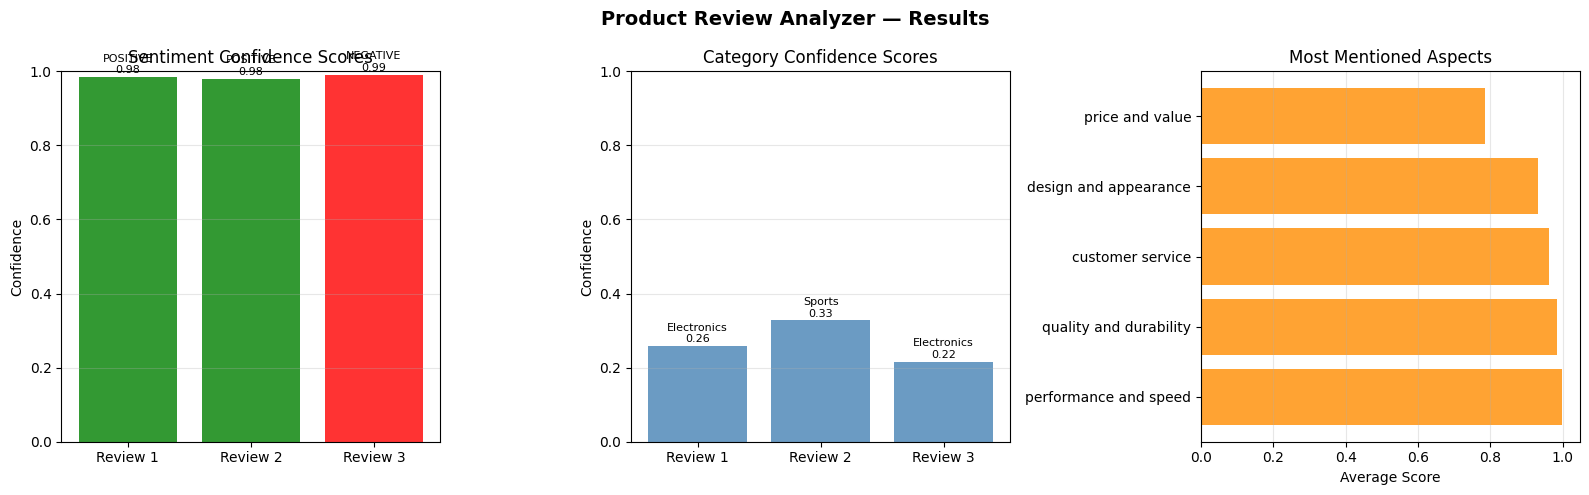

Results visualization saved!


In [51]:
# ── Visualize Results ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sentiment scores
sentiments = [r['sentiment']['label'] for r in results]
scores     = [r['sentiment']['score'] for r in results]
colors     = ['green' if s == 'POSITIVE'
              else 'red' for s in sentiments]

axes[0].bar([f"Review {i+1}" for i in range(len(results))],
            scores, color=colors, alpha=0.8)
axes[0].set_title('Sentiment Confidence Scores')
axes[0].set_ylabel('Confidence')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)
for i, (score, sentiment) in enumerate(
        zip(scores, sentiments)):
    axes[0].text(i, score + 0.01,
                 f'{sentiment}\n{score:.2f}',
                 ha='center', fontsize=8)

# Categories
categories = [r['category']['category'].split()[0]
              for r in results]
cat_scores = [r['category']['score'] for r in results]

axes[1].bar([f"Review {i+1}" for i in range(len(results))],
            cat_scores,
            color='steelblue', alpha=0.8)
axes[1].set_title('Category Confidence Scores')
axes[1].set_ylabel('Confidence')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)
for i, (score, cat) in enumerate(
        zip(cat_scores, categories)):
    axes[1].text(i, score + 0.01,
                 f'{cat}\n{score:.2f}',
                 ha='center', fontsize=8)

# Top aspects across all reviews
all_aspects = {}
for r in results:
    for aspect, score in r['aspects']:
        if aspect not in all_aspects:
            all_aspects[aspect] = []
        all_aspects[aspect].append(score)

avg_aspects = {k: np.mean(v)
               for k, v in all_aspects.items()}
avg_aspects = dict(sorted(avg_aspects.items(),
                           key=lambda x: x[1],
                           reverse=True)[:6])

axes[2].barh(list(avg_aspects.keys()),
             list(avg_aspects.values()),
             color='darkorange', alpha=0.8)
axes[2].set_title('Most Mentioned Aspects')
axes[2].set_xlabel('Average Score')
axes[2].grid(axis='x', alpha=0.3)

plt.suptitle('Product Review Analyzer — Results',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('analysis_results.png', dpi=150)
plt.show()
print("Results visualization saved!")

In [52]:
from huggingface_hub import login, create_repo, HfApi
from google.colab import userdata

token = userdata.get("HF_TOKEN")
login(token=token)

# Verify login
api = HfApi()
user = api.whoami()
print(f"Logged in as: {user['name']}")

# Save model + tokenizer locally first
sentiment_model.save_pretrained("./pranalyzer-model")
tokenizer.save_pretrained("./pranalyzer-model")

# Verify files are saved
import os
print("\nFiles saved:")
for f in os.listdir("./pranalyzer-model"):
    print(f"  {f}")

# Now push both
sentiment_model.push_to_hub("Ved2001/pranalyzer")
tokenizer.push_to_hub("Ved2001/pranalyzer")
print("\n✅ Model + tokenizer pushed!")

Logged in as: Ved2001


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Files saved:
  tokenizer_config.json
  tokenizer.json
  config.json
  model.safetensors


README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...5gspwg1/model.safetensors:   2%|2         | 6.30MB /  268MB            

No files have been modified since last commit. Skipping to prevent empty commit.



✅ Model + tokenizer pushed!
